# SIIM Meeting 2021 Hands-on Session

![SIIM21](https://siim.org/resource/resmgr/siim2021/banners/SIIM2021_banner2500x600.png)

# Basics of Image Processing - Reading, de-identification and anonymization - Session ID 1017

## Reading DICOM Images and Metadata, Viewing, psedonymization/anonymization

By the end of this presentation, you will be able to:
1. Read and write DICOM files
2. Read and modify specific DICOM tags
3. Visualize pixel data
4. Remove PHI from pixel data

In order to accomplish the proposed activities, you will need to:

1. Have a basic understanding of python programming
2. Have a basic knowledge of DICOM

This notebook was created by João Santinha (joao.santinha@gmail.com). Revision by Felipe Kitamura (kitamura.felipe@gmail.com) and Nuno Loução (nunoloucao@gmail.com).


### If using Google Colab we need to install required libraries before starting (if using Jupyter Notebooks this was already installed)

In [1]:
if 'google.colab' in str(get_ipython()):
    !git clone -q https://github.com/JoaoSantinha/SIIM21_BIP.git
    !pip install -q pydicom deid itk simpleitk napari[all]
    %cd ./SIIM21_BIP

## 1. Reading a DICOM Series

Lets first start with reading a DICOM series (group of dicom images belonging to same sequence acquisition). This could be 2D, 3D or 4D (3D+time or 3D+parameters).

In this case, pydicom, SimpleITK and ITK allow you to easily read the DICOM series.

The DICOM series is contained in the folder T1w_postContrast_Neuro and whithin you can find several .dcm files, each corresponding to a 2D slice of the 3D volume.

In [2]:
import os

os.listdir('T1w_postContrast_Neuro')

['000000.dcm',
 '000001.dcm',
 '000002.dcm',
 '000003.dcm',
 '000004.dcm',
 '000005.dcm',
 '000006.dcm',
 '000007.dcm',
 '000008.dcm',
 '000009.dcm',
 '000010.dcm',
 '000011.dcm',
 '000012.dcm',
 '000013.dcm',
 '000014.dcm',
 '000015.dcm',
 '000016.dcm',
 '000017.dcm',
 '000018.dcm',
 '000019.dcm',
 '000020.dcm',
 '000021.dcm',
 '000022.dcm',
 '000023.dcm',
 '000024.dcm',
 '000025.dcm',
 '000026.dcm',
 '000027.dcm',
 '000028.dcm',
 '000029.dcm',
 '000030.dcm',
 '000031.dcm',
 '000032.dcm',
 '000033.dcm',
 '000034.dcm',
 '000035.dcm',
 '000036.dcm',
 '000037.dcm',
 '000038.dcm',
 '000039.dcm',
 '000040.dcm',
 '000041.dcm',
 '000042.dcm',
 '000043.dcm',
 '000044.dcm',
 '000045.dcm',
 '000046.dcm',
 '000047.dcm',
 '000048.dcm',
 '000049.dcm',
 '000050.dcm',
 '000051.dcm',
 '000052.dcm',
 '000053.dcm',
 '000054.dcm',
 '000055.dcm',
 '000056.dcm',
 '000057.dcm',
 '000058.dcm',
 '000059.dcm',
 '000060.dcm',
 '000061.dcm',
 '000062.dcm',
 '000063.dcm',
 '000064.dcm',
 '000065.dcm',
 '000066.d

Each of these DICOM files contain both metadata (scanner information, acquisition settings, patient info, slice location, etc.), as well as, the pixel/voxel data (2D - pixel; 3D - voxel)

In [3]:
cT1w_data_dir = './T1w_postContrast_Neuro/'
dcm_filename = '000120.dcm'
dcm_filepath = os.path.join(cT1w_data_dir, dcm_filename)

### Reading DICOM Image and Metadata using pydicom

Pydicom was design to provide a pythonic way to work with DICOM files that can include medical image, reports, and radiotherapy objects. Usually it is used to allow DICOM metadata reading and modification (anonymization/de-identification).

Let's see how to look a DICOM file metadata and obtain the patient name, age, sequence parameters like echo time, repetition time, and slice thickness.

In [4]:
import pydicom

ds = pydicom.dcmread(dcm_filepath)

Print an overview of the DICOM metada. Notice it is composed by a tag (xxxx, xxxx), tag name (e.g. Group Length), value representation (e.g. UI - unique id; TM - time; DA - data; CS - code string, etc.), and value

In [5]:
ds

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 190
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.9328.50.16.281654496659260155563614379658381155324
(0002, 0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.40.0.13.1.1
(0002, 0013) Implementation Version Name         SH: 'dcm4che-1.4.27'
-------------------------------------------------
(0008, 0000) Group Length                        UL: 486
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M', 'ND', 'NORM']
(0008, 0016) SOP Class UID                       UI: MR Image Storage
(0008, 0018) SOP Instance UID                    UI: 1.3.6.1.4.1.9328.50.16.281654496

Lets retrieve patient name using the corresponding dicom metada tag name (without spaces!!!)

In [6]:
ds.PatientName # de-identified patient 

'281949'

Or alternatively using the corresponding DICOM metadata tag

In [7]:
ds[0x10,0X10].value

'281949'

In [8]:
ds.PatientBirthDate # empty due to anonymization

''

In [9]:
ds.EchoTime

'4.11'

In [10]:
ds.RepetitionTime

'8.6'

In [11]:
ds.SliceThickness

'1.0'

Lets view a slice

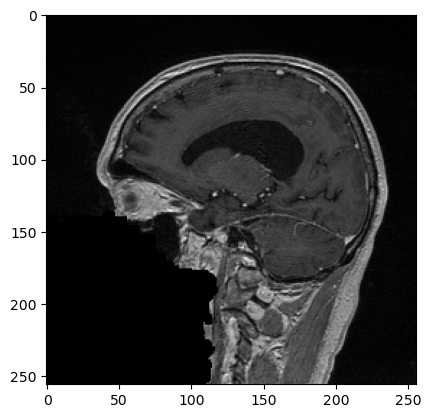

In [12]:
%matplotlib inline
# %matplotlib notebook 
import numpy as np
import matplotlib.pyplot as plt

slice_data = ds.pixel_array

plt.imshow(slice_data, cmap="gray")
plt.show()

## 2. Reading DICOM Image and Metadata using SimpleITK

We can also obtain metadata information using SimpleITK. SimpleITK offers additional function for filtering, segmentation and registeration of the images.

In [13]:
import SimpleITK as sitk

reader = sitk.ImageFileReader()

reader.SetFileName(dcm_filepath)
reader.LoadPrivateTagsOn()

reader.ReadImageInformation()

But its interface to obtain the metadata is a bit different. Lets list the tags to have an idea how to access them

In [14]:
print(reader.GetMetaDataKeys())

('0008|0000', '0008|0005', '0008|0008', '0008|0016', '0008|0018', '0008|0020', '0008|0023', '0008|0030', '0008|0032', '0008|0033', '0008|0050', '0008|0060', '0008|0070', '0008|0090', '0008|1010', '0008|1030', '0008|103e', '0008|1090', '0008|1150', '0008|1155', '0010|0000', '0010|0010', '0010|0020', '0010|0030', '0010|0040', '0012|0000', '0012|0062', '0012|0063', '0013|0000', '0013|0010', '0013|1010', '0013|1013', '0018|0000', '0018|0010', '0018|0015', '0018|0020', '0018|0021', '0018|0022', '0018|0023', '0018|0024', '0018|0025', '0018|0050', '0018|0080', '0018|0081', '0018|0083', '0018|0084', '0018|0085', '0018|0086', '0018|0087', '0018|0089', '0018|0091', '0018|0093', '0018|0094', '0018|0095', '0018|1000', '0018|1020', '0018|1030', '0018|1041', '0018|1200', '0018|1201', '0018|1251', '0018|1312', '0018|1314', '0018|1315', '0018|1316', '0018|1318', '0018|5100', '0020|0000', '0020|000d', '0020|000e', '0020|0010', '0020|0011', '0020|0012', '0020|0013', '0020|0032', '0020|0037', '0020|0052'

Lets get the patient name, age, sequence parameters like echo time, repetition time, and slice thickness using SimpleITK

In [15]:
print('Patient\'s Name', reader.GetMetaData('0010|0010'))
print('Slice Thickness', reader.GetMetaData('0018|0050'))
print('Repetition Time', reader.GetMetaData('0018|0080'))
print('Echo Time', reader.GetMetaData('0018|0081'))

Patient's Name 281949
Slice Thickness 1 
Repetition Time 8.6 
Echo Time 4.11


Similar to what we did using pydicom, lets now read the image and plot it

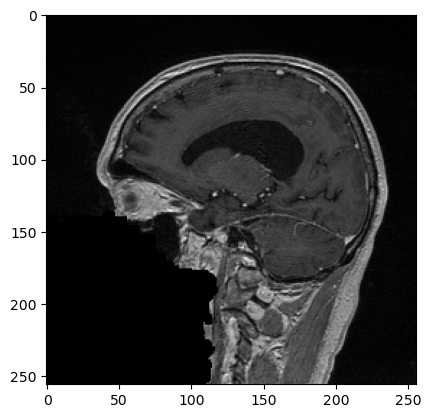

In [16]:
%matplotlib inline
image_slice = reader.Execute() # This is not a NumPy array, but a SimpleITK image object - we will see this later

image_slice_np = sitk.GetArrayFromImage(image_slice)[0,:,:]

plt.imshow(sitk.GetArrayFromImage(image_slice)[0,:,:], cmap="gray")
plt.show()

## 3. Reading DICOM Image/Series and Metadata using ITK

Although ITK is a C++ library it contains a wrapping in python which we will use.

This wrapping offers all the functionalities provived by the C++ implementation.

As you will see ITK is more verbose than SimpleITK but it more customizable and offers additional filters.

Lets get the patient name, age, sequence parameters like echo time, repetition time, and slice thickness using ITK

In [17]:
import itk

namesGenerator = itk.GDCMSeriesFileNames.New()
namesGenerator.SetUseSeriesDetails(True)
namesGenerator.SetGlobalWarningDisplay(False)
namesGenerator.SetDirectory(cT1w_data_dir)

seriesUIDs = namesGenerator.GetSeriesUIDs() #this gets the series UID that will allows us to separate two or more series in a folder 

uid = seriesUIDs[0]

dicom_names = namesGenerator.GetFileNames(uid)

PixelType = itk.ctype('signed short')
Dimension = 3

ImageType = itk.Image[PixelType, Dimension]

reader_itk = itk.ImageSeriesReader[ImageType].New()
dicomIO = itk.GDCMImageIO.New()
reader_itk.SetImageIO(dicomIO)
reader_itk.SetFileNames(dicom_names)
reader_itk.ForceOrthogonalDirectionOff()
reader_itk.Update()

metad = dicomIO.GetMetaDataDictionary()
print('Patient\'s Name', metad['0010|0010'])
print('Slice Thickness', metad['0018|0050'])
print('Repetition Time', metad['0018|0080'])
print('Echo Time', metad['0018|0081'])

Patient's Name 281949
Slice Thickness 1 
Repetition Time 8.6 
Echo Time 4.11


But we actually read the 3D volume represented by all the .dcm files. Let see what the object ITK image contains.

In [18]:
image_itk = reader_itk.GetOutput() # this loads all .dcm files and creates a 3D volume corresponding to the acquisition
print(image_itk) # this is not just voxel values, it contains image information like size, orientation, origin, etc.

Image (000001897B3A0570)
  RTTI typeinfo:   class itk::Image<short,3>
  Reference Count: 2
  Modified Time: 5943
  Debug: Off
  Object Name: 
  Observers: 
    none
  Source: (0000018977D31090) 
  Source output name: Primary
  Release Data: Off
  Data Released: False
  Global Release Data: Off
  PipelineMTime: 69
  UpdateMTime: 5944
  RealTimeStamp: 0 seconds 
  LargestPossibleRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [256, 256, 176]
  BufferedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [256, 256, 176]
  RequestedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [256, 256, 176]
  Spacing: [1, 1, 1]
  Origin: [86.1441, -139.893, 128]
  Direction: 
0 0 -1
1 0 0
0 -1 0

  IndexToPointMatrix: 
0 0 -1
1 0 0
0 -1 0

  PointToIndexMatrix: 
0 1 0
0 0 -1
-1 0 0

  Inverse Direction: 
0 1 0
0 0 -1
-1 0 0

  PixelContainer: 
    ImportImageContainer (000001897EC7B3F0)
      RTTI typeinfo:   class itk::ImportImageContainer<unsigned __int64,short>
      Reference 

## 4. Viewing 3D volumes and slices in jupyter notebook (Local installation or mybinder)
### Scroll to 4* if you are using Google Colab

Using ITK and Napari (as a modern alternative to itkwidgets), it is possible to visualize the 3D volume, change slices, windowing, view, among others.

In [31]:
import napari
import itk

# Convert the ITK image to a NumPy array for napari visualization
image_array = itk.array_from_image(image_itk)

# Open the image in the napari viewer
viewer = napari.view_image(image_array, name='MRI', colormap='gray')

# Start the napari event loop
napari.run()

Change colormap/CLUT (Color Look Up Table)

In [32]:
# Napari version with a different colormap (you can change to another color in the napari UI)
viewer = napari.view_image(image_array, name='MRI_Color', colormap='viridis')

napari.run()

You can also request the anatomical plane you wish to view by reordering the dimensions

In [33]:
viewer = napari.view_image(image_array, name='MRI_Axial_Plane', colormap='gray')

# Change the dimension order to slice through a different anatomical plane:
viewer.dims.order = (1, 2, 0) # You can also change directly in the napari UI

napari.run()

You can also switch the viewer to display a 3D volume rendering of the dataset

In [34]:
viewer = napari.view_image(image_array, name='MRI_3D', colormap='gray')

# Switch the viewer to 3D display mode
viewer.dims.ndisplay = 3

napari.run()

## 4*. Viewing slices from 3D volumes (Kudos to Paulo Kuriki)

In [23]:
#@title Load Python DICOM Viewer { vertical-output: true, display-mode: "form" }
# adapted from the amazing work of Paulo Kuriki (https://github.com/paulokuriki/feres_python_2021/blob/main/Python_for_Rads_(Feres_Secaf_2021).ipynb)
dicom_images_list = []
for dicom_file in dicom_names:
    # Read the DICOM file and store it in a pydicom.Dataset object
    ds = pydicom.dcmread(dicom_file)

    slope = float(ds.RescaleSlope)
    intercept = float(ds.RescaleIntercept)
    img_pixel_array = intercept + ds.pixel_array * slope
    dicom_images_list.append({'filename': dicom_file, 'pixel_array': img_pixel_array})

def show_dicom_image(scroll, window_level, window_width, zoom, predefined_window):

    if predefined_window == 'lung':
        window_level = -600
        window_width = 1500
    elif predefined_window == 'mediastinum':
        window_level = 50
        window_width = 350
    elif predefined_window == 'bone':
        window_level = 400
        window_width = 1800

    vmin = window_level - (window_width / 2)
    vmax = window_level + (window_width / 2)

    plt.figure(figsize=(zoom, zoom))
    plt.axis('off')
    img_pixel_array = dicom_images_list[scroll-1].get('pixel_array',0)

    plt.imshow(img_pixel_array, vmin=vmin, vmax=vmax, cmap='gray')

    print(f"Slice: {scroll}     WL: {window_level}     WW: {window_width}     Zoom: {zoom}")
    
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact

total_images = len(dicom_names)

scroll = widgets.IntSlider(value=int(total_images/2), min=1, max=total_images, step=1, description='Scroll:', continuous_update=True,
    orientation='horizontal', readout=True, readout_format='d')
window_level = widgets.IntSlider(value=300, min=0, max=1000, step=1, description='Window Level:', continuous_update=True,
    orientation='horizontal', readout=True, readout_format='d')
window_width = widgets.IntSlider(value=350, min=0, max=1000, step=1, description='Window Width:', continuous_update=True,
    orientation='horizontal', readout=True, readout_format='d')
zoom = widgets.IntSlider(value=10, min=1, max=10, step=1, description='Zoom:', continuous_update=True,
    orientation='horizontal', readout=True, readout_format='d')
predefined_window = ["custom", "lung", "mediastinum", "bone"]

interact(show_dicom_image, scroll=scroll, window_level=window_level, window_width=window_width, zoom=zoom, predefined_window=predefined_window)

interactive(children=(IntSlider(value=88, description='Scroll:', max=176, min=1), IntSlider(value=300, descrip…

<function __main__.show_dicom_image(scroll, window_level, window_width, zoom, predefined_window)>

Finally we will save the 3D volume in a single file for easier handling in the next notebooks.

In [24]:
writer = itk.ImageFileWriter[ImageType].New()
outFileName = './cT1wNeuro.nrrd'
writer.SetFileName(outFileName)
writer.UseCompressionOn()
writer.SetInput(image_itk)
print('Writing: ' + outFileName)
writer.Update()

Writing: ./cT1wNeuro.nrrd


## 5. Anonymizing/Psedonymization DICOMs

An important step that often has to be performed is the removal of protected health information (PHI) from the DICOM files. These may be in the metadata but also burned in your images.

The removal of such data through a reversible procedure where the identity of the patient may be retrieved if need, being procedure called psedonymization. On the other hand, if the procedure is done without keeping the association between new ids and old ids and other tags (irreversible), we will be doing anonymization.

3D reconstructions of Head MRIs and CTs may also be used to identify patients. For this specific case, defacing techniques may be employed to prevent such identification.

In this part we will use an Ultrasound image to remove the PHI.

But before starting it is important to know that certain attributes in the DICOM metadata are required and the removal will result in an unusable DICOM file.

#### DICOM Attribute Requirement Types
| | |
|:-|:-|
|  Type 1 | It is required in the SOP (Service Object Pair) instance and must have a valid value                                                         |
|  Type 2 | It is required in the SOP instance but can contain the value "unknown" or a value of length 0                                                |
|  Type 3 | Optional. May or may not be included and a length value of 0                                                                                 |
| Type 1C | Conditional. If a condition is met, then it is of type 1 (mandatory, cannot be null). If the condition is not met, then the tag is not sent. |
| Type 2C | Conditional. If a condition is met, then it is a type 2 (required, length zero OK). If the condition is not met, then the tag is not sent.   |

[more details](http://dicom.nema.org/dicom/2013/output/chtml/part05/sect_7.4.html)

#### Depending on the modality we may have different module requirements. Below you can find some examples (CR, MR and CT).

[CR IOD module requirements](http://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_A.2.3.html) - 
The modules marked with M are mandatory, C are conditional, U are optional (user option).

[CT IOD module requirements](http://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_A.3.3.html)

[MR IOD module requirements](http://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_A.4.3.html)

#### Inside each module we will have the DICOM Attribute Requirements type defined in the column type:

[Patient module attributes](http://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_C.7.html#sect_C.7.1.1)


### Removing PHI from DICOM metadata using deid library
Read image and print DICOM metadata

In [25]:
import pydicom

us_dicom_file = './us_sample.dcm'
ds = pydicom.dcmread(us_dicom_file)
ds

The value length (26) exceeds the maximum length of 16 allowed for VR SH.


Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 188
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Ultrasound Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.276.0.26.1.1.1.2.2017.272.1073.7895024.5
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.826.0.1.3680043.2.1396.999
(0002, 0013) Implementation Version Name         SH: 'CharruaSoft'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'OBSTETRICAL', '0040']
(0008, 0016) SOP Class UID                       UI: Ultrasound Image Storage
(0008, 0018) SOP Instance UID                    UI: 1.2.276.0.26.1.1.1.2.2017.272.1073.7895024.5
(0008, 0020) Study Date       

#### Visualize DICOM image

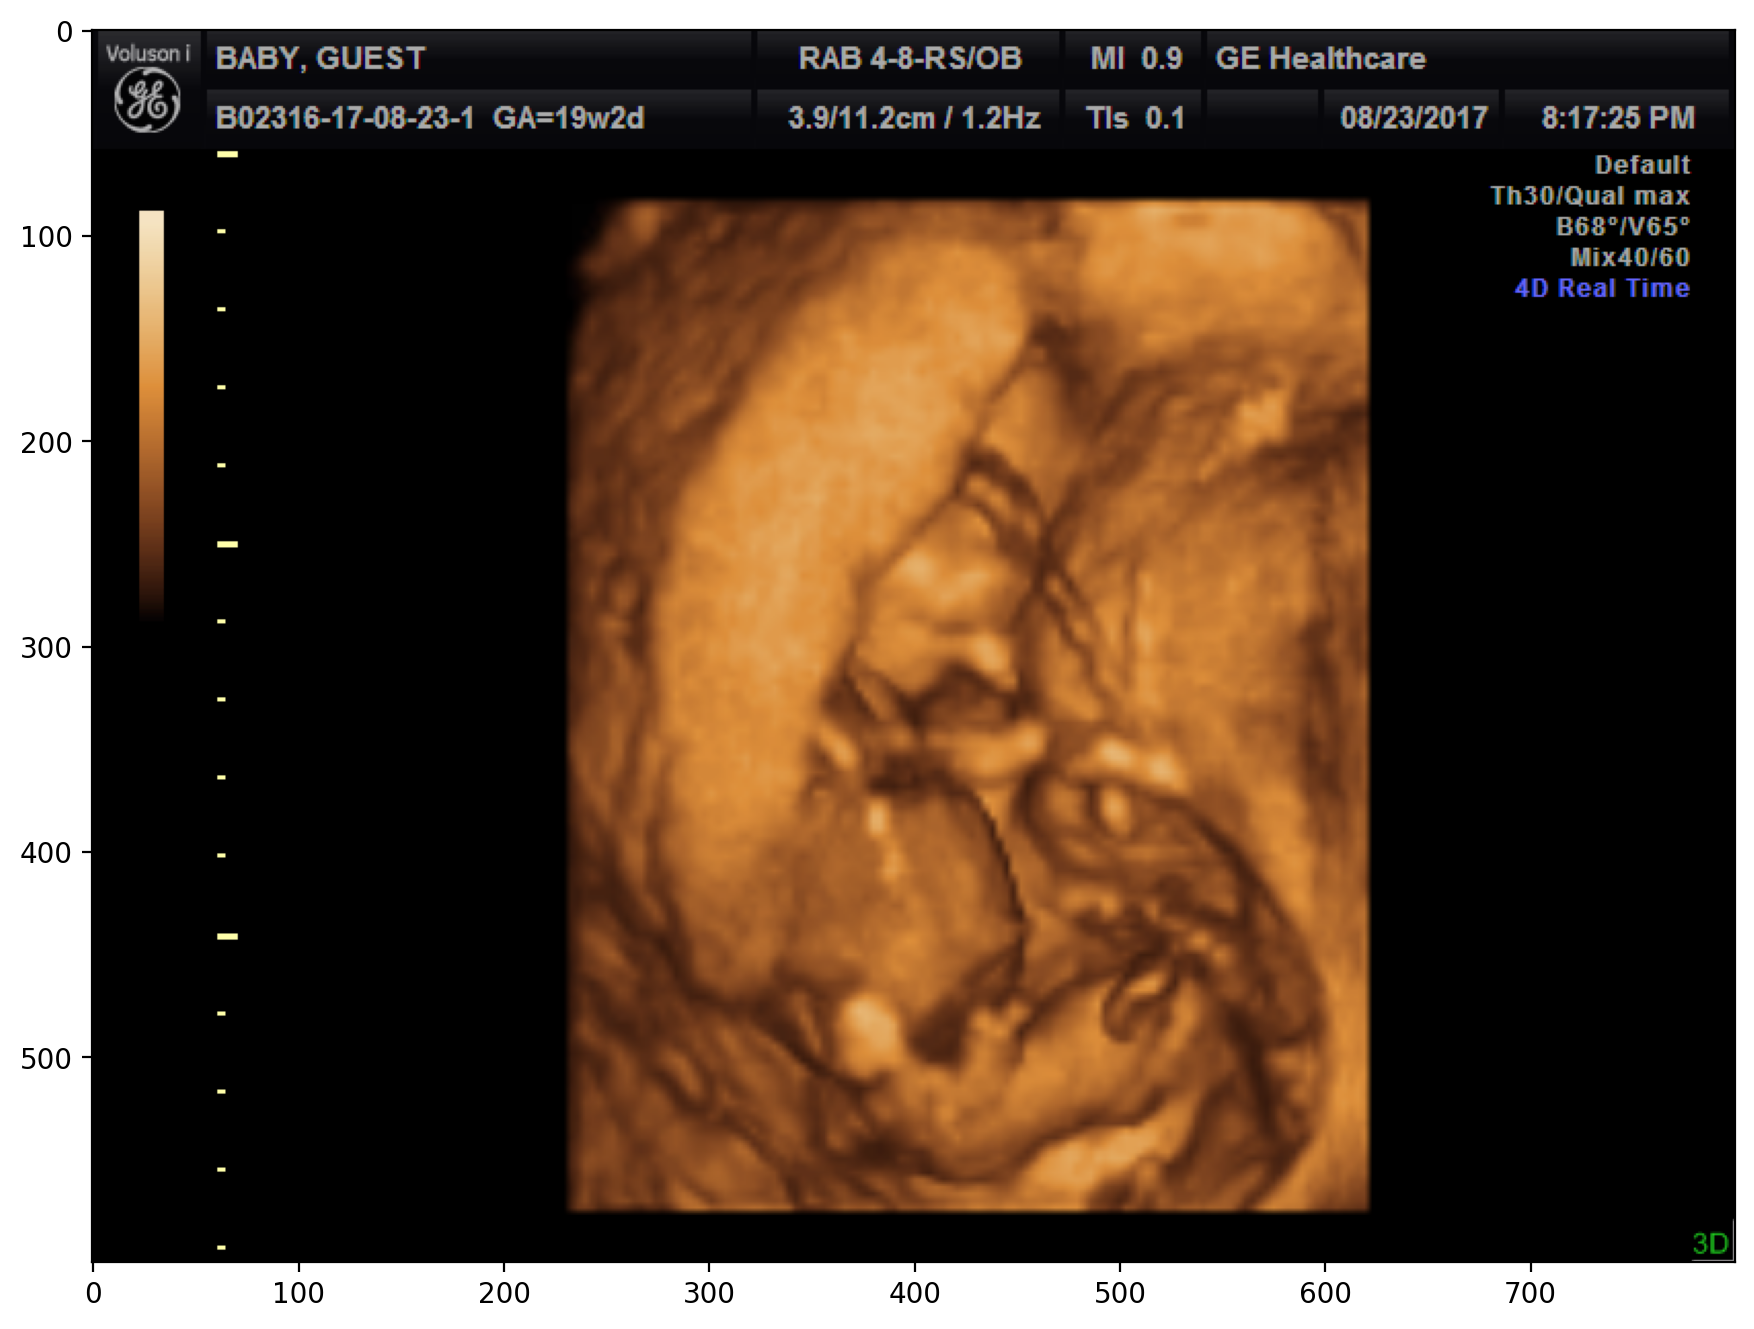

In [26]:
import numpy as np
from matplotlib import pyplot as plt

# set parameters for bigger image display in notebook
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 200

# show DICOM image
plt.imshow(ds.pixel_array)

##### As you can see we have burned in patient information (dummy) in the image, so besides the DICOM metadata we also need to remove this information from our images

### 5.1 Clean DICOM Metadata using pseudonymization/anonymization recipe

In [27]:
from deid.config import DeidRecipe
from deid.dicom import get_identifiers, replace_identifiers

# Load recipe file
recipe = DeidRecipe(deid='deid.dicom.ultrasound')

# Get DICOM identifiers
ids = get_identifiers(us_dicom_file)

# Update metadata tags
updated_ids = dict()
count = 0
for image, fields in ids.items():
    fields['entity_timestamp'] = '19740425' # Patient birth date
    fields['item_timestamp'] = '20180622'   # Study date
    fields['entity_id'] = '2031988'         # Patient ID
    fields['item_id'] = '136234'            # Accession number
    updated_ids[image] = fields
    count += 1

# Execute cleaning and save the updated DICOM 
# (Note: overwrite=True is set to allow running this cell multiple times without errors)
cleaned_files = replace_identifiers(dicom_files=us_dicom_file, deid=recipe, ids=updated_ids, overwrite=True, output_folder='./deid_anonym', save=True)

# Read and output the updated DICOM tags using dcmread 
pydicom.dcmread(cleaned_files[0])

The value length (82) exceeds the maximum length of 64 allowed for VR LO.
Invalid value for VR CS: 'Yes'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.


Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 100
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.826.0.1.3680043.2.1396.999
(0002, 0013) Implementation Version Name         SH: 'CharruaSoft'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'OBSTETRICAL', '0040']
(0008, 0020) Study Date                          DA: '20180622'
(0008, 0050) Accession Number                    SH: '136234'
(0008, 0060) Modality                            CS: 'US'
(0008, 0070) Manufacturer                        LO: 'Kretztechnik'
(0008, 0080) Institution Name                    LO: '???'
(0008, 1010) Station Name                        SH: 'US1'
(0008, 1090)

#### Additional deid recipes
In [deid Github repository](https://github.com/pydicom/deid) you can find additional examples of different recipes, including [a general file built with the knowledge of several deid users](https://github.com/pydicom/deid/blob/master/deid/data/deid.dicom) for anonymizing/pseudonymizing DICOM metadata and burned in PHI of dicoms several scanners

#### Now that we have cleaned the DICOM metadata let's see how we can clean the Pixel Data (Image)
Using the rules defined in the recipe file, the deid library is able to flag images that likely will have burned in PHI

Here is how you can do this

In [28]:
from deid.dicom import get_files, has_burned_pixels
from deid.config import DeidRecipe
from pydicom import dcmread
from deid.data import get_dataset
from deid.logger import bot
import os

# Set logging level
bot.level = 3

# Check if DICOM files have burned-in pixels (PHI)
dicom_files = list([cleaned_files[0]])
results = has_burned_pixels(dicom_files=dicom_files, deid=recipe)

print(results)

{'clean': [], 'flagged': {'./deid_anonym\\us_sample.dcm': {'flagged': True, 'results': [{'reason': 'and Manufacturer contains Kretztechnik Modality contains US ManufacturerModelName contains V730 Rows equals 600', 'group': 'graylist', 'coordinates': [[0, '0,0,1140,60']]}]}}}


### 5.2 Clean the image pixels containing PHI

In [29]:
from deid.dicom import DicomCleaner
from deid.dicom import get_files
from deid.data import get_dataset

dicom_file = us_dicom_file

# create cleaner
cleaner = DicomCleaner(output_folder="./deid_anonym",deid="deid.dicom.ultrasound")

# using the deid recipe parse hearders using detect()
cleaner.detect(dicom_file)

# execute cleaning of image
cleaner.clean()

# save result to DICOM (automatically prefixed by 'cleaned_')
cleaner.save_dicom() 
# you can also save it as .png image using
# cleaner.save_png()

Scrubbing ./us_sample.dcm.


'./deid_anonym/cleaned-us_sample.dcm'

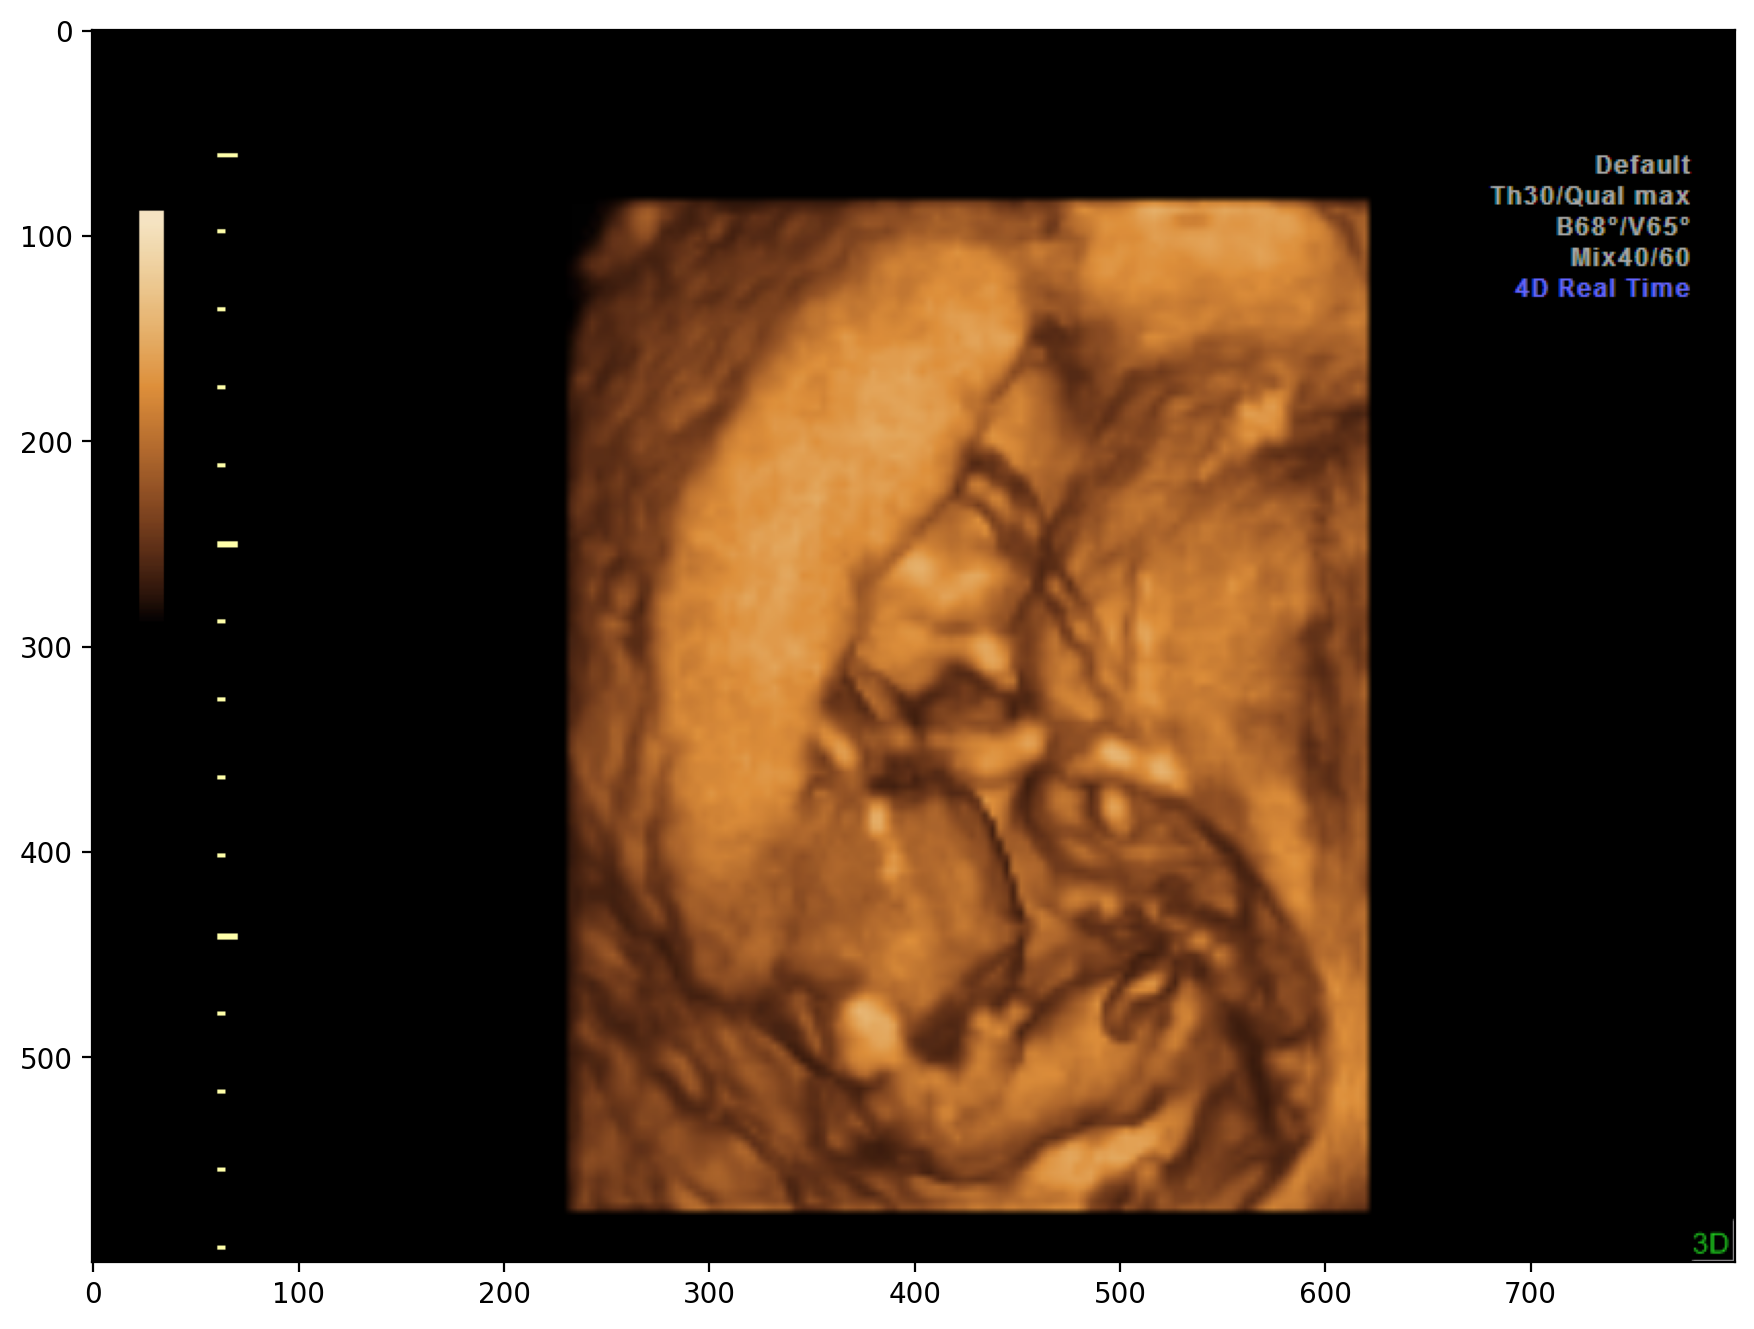

In [30]:
%matplotlib inline 
cleaned_us_dicom_file = './deid_anonym/cleaned-us_sample.dcm'
ds_cleaned = pydicom.dcmread(cleaned_us_dicom_file)
plt.imshow(ds_cleaned.pixel_array)
plt.show() 